# Spam Detection - Baseline_v4
**Step 4: Hyperparameter Optimization & Experiments**

## 1. Data Loading + İlk Bakış

In [1]:
import pandas as pd

file_path = "../data/raw/spam.csv"

df = pd.read_csv(file_path, encoding='latin-1')

print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Shape: (5572, 5)


## 2. Dataset Düzenleme

In [2]:
# Gereksiz sütunları at, sadece v1 ve v2'yi al
df = df[['v1', 'v2']]

# Kolon isimlerini değiştir
df.columns = ['label', 'text']

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Temizlik

In [3]:
# Boş değerleri sil
df = df.dropna()

# Duplicate kontrolü
df = df.drop_duplicates()

print("After cleaning:", df.shape)

After cleaning: (5169, 2)


## 4. Label Encoding

In [4]:
# ham -> 0, spam -> 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Dağılım
print(df['label'].value_counts())
print("\nClass distribution (%):\n", df['label'].value_counts(normalize=True).round(3) * 100)

label
0    4516
1     653
Name: count, dtype: int64

Class distribution (%):
 label
0    87.4
1    12.6
Name: proportion, dtype: float64


## 5. Train / Val / Test Split (Stratified)

In [5]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

# %70 train, %30 temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# %15 val, %15 test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))

Train: 3618
Val:   775
Test:  776


## 6. TF-IDF Vectorization

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)

TF-IDF matrix shape (train): (3618, 5000)


## 7. Baseline Model — Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred), 4))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Accuracy:  0.9691
Precision: 1.0
Recall:    0.7551
F1 Score:  0.8605

--- Classification Report ---
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       678
        spam       1.00      0.76      0.86        98

    accuracy                           0.97       776
   macro avg       0.98      0.88      0.92       776
weighted avg       0.97      0.97      0.97       776



## 8. Confusion Matrix

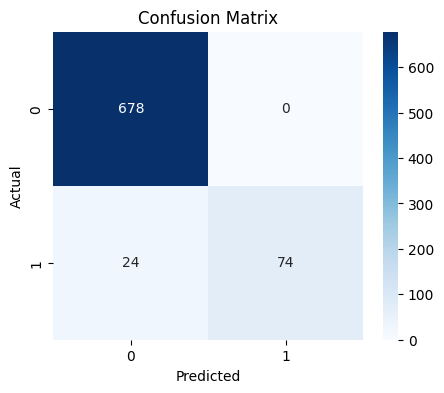

[[678   0]
 [ 24  74]]


In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(cm)
# Beklenen yapı:
# [[ham doğru,   ham→spam hata ]
#  [spam→ham hata, spam doğru  ]]

## 8. PyTorch Dataset & DataLoader

In [16]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Sparse → dense → tensor
X_train_tensor = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_tfidf.toarray(),   dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_tfidf.toarray(),  dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values,  dtype=torch.float32)

# Dataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)
test_loader  = DataLoader(test_dataset,  batch_size=32)

print("DataLoader hazır")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

# Sanity check
X_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: X={X_batch.shape}, y={y_batch.shape}")

DataLoader hazır
Train batches: 114 | Val batches: 25 | Test batches: 25
Batch shape: X=torch.Size([32, 5000]), y=torch.Size([32])


## 9. Spam MLP Modeli (PyTorch)

In [17]:
def train_model(dropout_p=0.4, weight_decay=1e-4, l1_lambda=0.00005, num_epochs=50, patience=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    mlp_model = SpamMLP(input_dim=5000, hidden1=256, hidden2=128).to(device)
    
    def init_weights_he(m):
        import torch.nn as nn
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
                
    mlp_model.apply(init_weights_he)
    
    optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    import torch.nn as nn
    criterion = nn.BCEWithLogitsLoss()
    
    best_val_loss = float('inf')
    best_wts = None
    counter = 0
    
    for epoch in range(num_epochs):
        mlp_model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = mlp_model(X_b)
            loss = criterion(logits, y_b)
            
            # L1
            l1_reg = torch.tensor(0., device=device)
            for param in mlp_model.parameters():
                l1_reg += torch.norm(param, 1)
            loss += l1_lambda * l1_reg
            
            loss.backward()
            optimizer.step()
            
        mlp_model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out = mlp_model(X_b)
                v_loss += criterion(out, y_b).item() * X_b.size(0)
        v_loss /= len(val_loader.dataset)
        
        scheduler.step(v_loss)
        
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            import copy
            best_wts = copy.deepcopy(mlp_model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience: break
            
    return best_val_loss, best_wts

print("Experiment function ready.")

Experiment function ready.


## 10- EĞİTİM DÖNGÜSÜ VE BİLİNÇLİ OVERFITTING (TRAINING LOOP)

In [19]:
import matplotlib.pyplot as plt
import copy
import torch

NUM_EPOCHS = 100 # Early stopping için limiti yüksek tutuyoruz
Patience = 5
best_val_loss = float('inf')
counter = 0

# Modeli yeniden örnekle (İsim dl_model yerine mlp_model olarak güncellendi)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model = SpamMLP(input_dim=5000, hidden1=256, hidden2=128).to(device)

# He (Kaiming) Normal Initialization
def init_weights_he(m):
    import torch.nn as nn
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

mlp_model.apply(init_weights_he)

# Gelişmiş Optimizer
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)

# LR Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
import torch.nn as nn
criterion = nn.BCEWithLogitsLoss()

best_model_wts = copy.deepcopy(mlp_model.state_dict())

train_losses = []
val_losses = []

print(f"Eğitim başlatıldı (Max Epochs: {NUM_EPOCHS}, Patience: {Patience})...")

for epoch in range(NUM_EPOCHS):
    # --- Eğitim ---
    mlp_model.train()
    train_running = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = mlp_model(X_batch)
        loss = criterion(logits, y_batch)

        # L1 Regularization Testi
        l1_lambda = 0.00005
        l1_reg = torch.tensor(0., device=device)
        for param in mlp_model.parameters():
            l1_reg += torch.norm(param, 1)
        loss += l1_lambda * l1_reg

        loss.backward()
        optimizer.step()

        train_running += loss.item() * X_batch.size(0)

    train_loss_avg = train_running / len(train_loader.dataset)

    # --- Doğrulama ---
    mlp_model.eval()
    val_running = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = mlp_model(X_batch)
            loss = criterion(logits, y_batch)
            val_running += loss.item() * X_batch.size(0)

    val_loss_avg = val_running / len(val_loader.dataset)

    train_losses.append(train_loss_avg)
    val_losses.append(val_loss_avg)

    # Scheduler'ı güncelle
    scheduler.step(val_loss_avg)

    # Early Stopping Kontrolü
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        best_model_wts = copy.deepcopy(mlp_model.state_dict())
        counter = 0 # Val loss iyileştiği için sayacı sıfırla
    else:
        counter += 1
        if counter >= Patience:
            print(f"\n>>> Early Stopping tetiklendi! Epoch: {epoch+1} (Daha fazla iyileşme yok)")
            break

    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch + 1:2d}/{NUM_EPOCHS} | Train Loss: {train_loss_avg:.6f} | Val Loss: {val_loss_avg:.6f}")

# En iyi ağırlıkları yükle
mlp_model.load_state_dict(best_model_wts)
print("\nEğitimin en iyi (lowest val loss) model ağırlıkları yüklendi.")

# --- Kayıp eğrileri ---
epochs_axis = range(1, len(train_losses) + 1)
plt.figure(figsize=(10, 6))
plt.plot(epochs_axis, train_losses, 'b-', label='Train Loss', alpha=0.8)
plt.plot(epochs_axis, val_losses, 'r-', label='Val Loss', alpha=0.8)
plt.axvline(x=len(train_losses) - counter, color='g', linestyle='--', label='Best Model Saved')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Step 3: Optimization with Early Stopping and L1/L2")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

AttributeError: 'LogisticRegression' object has no attribute 'state_dict'

## Step 4: Hyperparameter Experiments
Bu bölümde farklı hiperparametre kombinasyonlarını (Dropout, Weight Decay, L1 Lambda) test ederek en iyi performansı (Validation Loss) veren modeli belirliyoruz.

In [ ]:
results = []
configs = [
    {'wd': 1e-4, 'l1': 1e-5},
    {'wd': 1e-5, 'l1': 5e-5},
    {'wd': 0.0,  'l1': 0.0} # No reg baseline comparison
]

for cfg in configs:
    print(f"Testing: WD={cfg['wd']}, L1={cfg['l1']}...")
    loss, _ = train_model(weight_decay=cfg['wd'], l1_lambda=cfg['l1'])
    results.append({'config': cfg, 'loss': loss})
    print(f"-> Val Loss: {loss:.6f}")

best_result = min(results, key=lambda x: x['loss'])
print(f"\nEn Başarılı Konfigürasyon: {best_result['config']} | Loss: {best_result['loss']:.6f}")